In [27]:

# ======================================================
# TITANIC DATASET - DECISION TREE CLASSIFICATION PROJECT
# ======================================================

# ------------------------------------------------------
# STEP 1: IMPORT REQUIRED LIBRARIES
# ------------------------------------------------------

# pandas -> used for data handling and analysis
import pandas as pd

# matplotlib -> used for plotting graphs
import matplotlib.pyplot as plt

# train_test_split -> used to divide dataset into training and testing data
from sklearn.model_selection import train_test_split

# DecisionTreeClassifier -> Decision Tree Machine Learning algorithm
from sklearn.tree import DecisionTreeClassifier

# accuracy_score -> used to check model accuracy
from sklearn.metrics import accuracy_score

# plot_tree -> used to visualize the decision tree
from sklearn.tree import plot_tree

In [29]:
#------------------------------------------------------
# STEP 2: LOAD THE TITANIC DATASET
# ------------------------------------------------------

 
# Read CSV file into dataframe
# DataFrame is like an Excel table in Python

 
df = pd.read_csv(r"C:\Users\wadje\Desktop\Learnbay\Machine Learning\Dataset\Titanic-Dataset.csv")
df.head()
 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [31]:
# ------------------------------------------------------
# STEP 3: UNDERSTAND THE DATASET
# ------------------------------------------------------

# Display information about dataset
print("\nDataset Information:\n")
print(df.info())

# Check missing values in each column
print("\nMissing Values:\n")
print(df.isnull().sum())


Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

Missing Values:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Emba

In [42]:
# ------------------------------------------------------
# STEP 4: DATA CLEANING
# ------------------------------------------------------

# Machine learning models do not work well with missing values.
# So we clean the data.

# Fill missing Age values using median age
# Median is used because it handles outliers better.

df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values using most frequent value

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column because it has too many missing values

df.drop('Cabin', axis=1, inplace=True)

In [44]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [56]:
# ------------------------------------------------------
# STEP 5: CONVERT CATEGORICAL DATA TO NUMBERS
# ------------------------------------------------------

# Machine learning algorithms understand only numbers.
# So we convert text values into numeric values.

# Convert Gender column
# male = 0
# female = 1

df['Sex'] = df['Sex'].map({'male' : 0, 'female' : 1})

# Convert Embarked column into dummy variables
# Creates columns like Embarked_Q and Embarked_S
df = pd.get_dummies(df, columns = ['Embarked'], drop_first = True)    # Dropping one column from one hot encoding as we can predict its value based on others

In [62]:
# ------------------------------------------------------
# STEP 6: SELECT FEATURES AND TARGET VARIABLE
# ------------------------------------------------------

# Features (Independent Variables) - input 
# These columns help predict survival.

x = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
        'Embarked_Q', 'Embarked_S']]

# Target Variable (Dependent Variable)
# This is what we want to predict.

y = df['Survived']

In [64]:
# ------------------------------------------------------
# STEP 7: SPLIT DATA INTO TRAINING AND TESTING DATA
# ------------------------------------------------------

# 80% data -> Training
# 20% data -> Testing

# Training data is used to teach the model.
# Testing data is used to evaluate model performance.

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [69]:
#------------------------------------------------------
# STEP 8: CREATE DECISION TREE MODEL
# ------------------------------------------------------

# Create Decision Tree object

model = DecisionTreeClassifier(
    criterion = 'gini',
    max_depth = 4,
    random_state = 42
)
# criterion='gini'
# Gini impurity is used to decide the best split.

# max_depth=4
# Limits tree size to avoid overfitting.

# Train the model using training data

model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [71]:
# ------------------------------------------------------
# STEP 9: MAKE PREDICTIONS
# ------------------------------------------------------

# Predict survival using testing data

y_pred = model.predict(x_test)

# Display first 10 predictions
print("\nFirst 10 Predictions:\n")
print(y_pred[:10])


First 10 Predictions:

[0 0 0 1 0 1 0 0 0 0]


In [73]:
# ------------------------------------------------------
# STEP 10: EVALUATE MODEL PERFORMANCE
# ------------------------------------------------------

# Calculate accuracy score

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:\n")
print(accuracy)


Model Accuracy:

0.7150837988826816


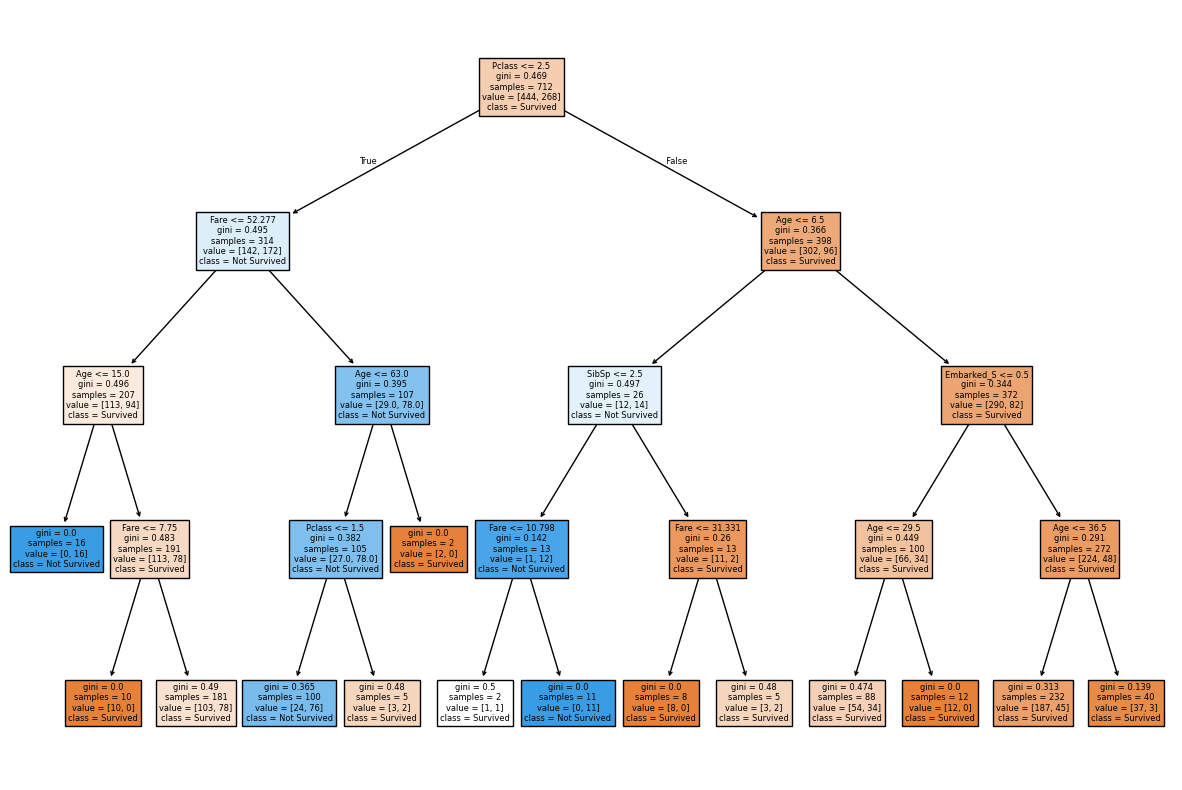

In [75]:
# ------------------------------------------------------
# STEP 11: VISUALIZE THE DECISION TREE
# ------------------------------------------------------

# Plot decision tree

plt.figure(figsize = (15,10))

plot_tree(
    model,
    feature_names = x.columns,
    class_names = ['Survived', 'Not Survived'],
    filled = True
)

# Display tree diagram
plt.show()

#Condition → Decision
#Gini → Purity
#Samples → How many rows
#Value → Class counts
#Class → Final prediction